# Building a Blend-Severity Classifier — the Basics

This notebook builds a small image classifier **from scratch**, step by step, so you can
see every piece: the data, the network, the training loop, and how to read the results.

**The task:** each image is a 64x64, 3-band (g/r/i) cutout centered on one detected
galaxy. Some cutouts show a single isolated galaxy; others show a galaxy overlapping
with a neighbor. We classify each cutout into one of 4 ordered severity classes:

1. **Clean / isolated** — no visible neighbor
2. **Moderate blend** — a neighbor overlaps but the two are separable
3. **Severe blend** — heavy overlap, hard to separate
4. **Ambiguous overlap** — unclear if this is 1 or 2 objects

**How to use this notebook:** run all the cells top to bottom once to see it work.
Then go back to the **Settings** cell (Section 1), change one thing, and re-run
everything below it (`Kernel -> Restart Kernel and Run All Cells` is the safest way).
Section 9, at the very end, has a list of specific things to try.

In [1]:
import json     # to read meta.json
import os       # to build file paths
import sys      # to add the repo root to Python's import search path

import matplotlib.pyplot as plt  # plotting
import numpy as np               # array math
import pandas as pd              # reading labels.parquet, a table of one row per cutout
import torch                     # the neural network library ("PyTorch")
import torch.nn as nn            # the building blocks (layers) for defining a network
from sklearn.metrics import (    # ready-made evaluation metrics, so we don't hand-roll them
    balanced_accuracy_score, classification_report, cohen_kappa_score, confusion_matrix,
)
from torch.utils.data import DataLoader, WeightedRandomSampler  # batch/sample the dataset for training

# this notebook lives in notebooks/, so the repo root is one level up
REPO_ROOT = os.path.abspath("..")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)  # lets us `import seed_classifier...` below

# reuse the project's own (already-tested) data-loading code, rather than
# reimplementing cutout loading/normalization/splitting from scratch here
from seed_classifier.data.dataset import (
    BlendCutoutDataset, class_sample_weights, compute_norm_stats, scene_split,
)

NUM_CLASSES = 4
CLASS_NAMES = ["clean", "moderate", "severe", "ambiguous"]  # index i corresponds to class label i+1

DATA_DIR = os.path.join(REPO_ROOT, "data", "sim", "run001")  # where images.npy / labels.parquet live

## 1. Settings

Everything you can change lives in this one dictionary. Change a value, re-run this
cell and everything below it, and see what happens to the results in Section 8.

In [2]:
CONFIG = {
    # -- data --
    "val_frac": 0.2,   # fraction of scenes held out for validation
    "seed": 0,         # random seed, for reproducibility

    # -- network architecture --
    "num_conv_blocks": 3,  # how many (conv -> batchnorm -> relu -> pool) blocks to stack. try 2-5.
    "base_channels": 16,   # filters in the first conv block (doubles every block after that)
    "fc_hidden": 64,       # size of the fully-connected hidden layer before the final output
    "dropout": 0.3,        # dropout probability in the fully-connected head

    # -- training --
    "epochs": 15,
    "batch_size": 64,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "grad_clip": 1.0,             # cap on gradient size per step, keeps training stable
    "use_class_weighting": True,  # if True, oversample rare classes so each batch sees them more evenly
    "use_augmentation": True,     # if True, randomly flip/rotate images during training
}

## 2. Load the data

`images.npy` holds every cutout as a `(3, 64, 64)` array (bands g, r, i). `labels.parquet`
holds one row per cutout with its `class` (1-4) and the `scene_id` it came from — cutouts
from the same simulated scene share a noise realization, which matters in Section 4.

In [3]:
labels_df = pd.read_parquet(os.path.join(DATA_DIR, "labels.parquet"))  # one row per cutout
with open(os.path.join(DATA_DIR, "meta.json")) as f:
    meta = json.load(f)          # dataset-level info: band names, image size, etc.
n_bands = len(meta["bands"])     # 3 (g, r, i) -- how many channels our images have

print(f"{len(labels_df):,} cutouts from {labels_df['scene_id'].nunique():,} scenes")
print(f"bands: {meta['bands']}, cutout size: {meta['stamp_size']}x{meta['stamp_size']}")
labels_df["class"].value_counts().sort_index()  # how many cutouts of each class (1-4)

6,013 cutouts from 500 scenes
bands: ['g', 'r', 'i'], cutout size: 64x64


class
1    5105
2     485
3     307
4     116
Name: count, dtype: int64

## 3. Look at the data

Two things worth seeing before training anything: how imbalanced the classes are, and
what each class actually looks like.

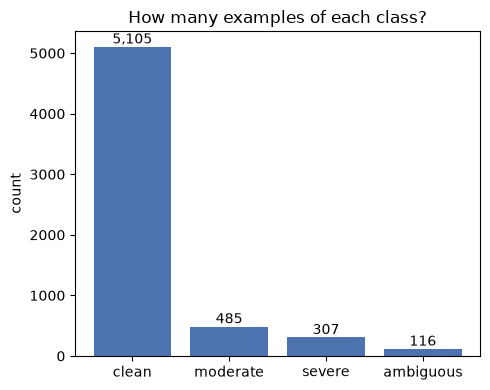

In [4]:
counts = labels_df["class"].value_counts().sort_index()  # count of each class label, 1-4
fig, ax = plt.subplots(figsize=(5, 4))                    # a blank figure with one set of axes
ax.bar(CLASS_NAMES, [counts.get(i, 0) for i in range(1, NUM_CLASSES + 1)], color="#4C72B0")
ax.set_ylabel("count")
ax.set_title("How many examples of each class?")
for i in range(NUM_CLASSES):
    ax.text(i, counts.get(i + 1, 0), f"{counts.get(i + 1, 0):,}", ha="center", va="bottom")  # count label above each bar
plt.tight_layout()  # avoid clipped/overlapping labels
plt.show()

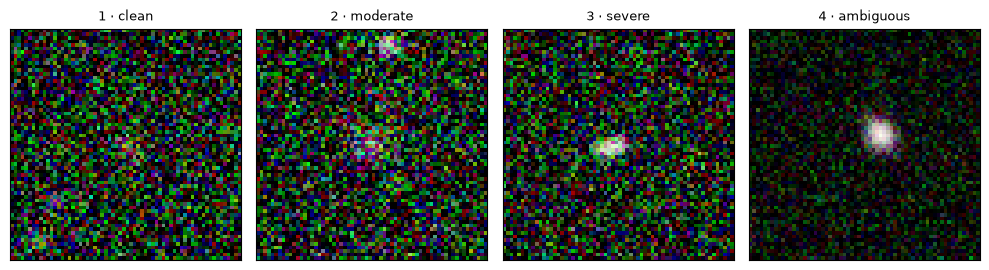

In [5]:
def to_rgb(img):
    # img is (3, H, W): one 64x64 array per band, in order g, r, i.
    # This is *only* for human viewing -- the network below reads the raw arrays directly.
    g, r, i = img[0], img[1], img[2]
    rgb = np.stack([i, r, g], axis=-1)              # reorder to (H, W, 3) as RGB=(i, r, g): redder band -> red channel
    scale = np.percentile(rgb, 99.5)                 # a brightness reference that ignores extreme outlier pixels
    scale = scale if scale > 0 else 1.0              # guard against an all-zero/negative cutout
    stretched = np.arcsinh(rgb / (scale / 3))         # arcsinh "stretch": compresses bright pixels, keeps faint ones visible
    return np.clip(stretched / stretched.max(), 0, 1) if stretched.max() > 0 else stretched  # rescale to [0, 1] for imshow


# mmap_mode="r" means: don't load the whole (large) file into RAM, read only the
# slices we actually index into below
images_arr = np.load(os.path.join(DATA_DIR, "images.npy"), mmap_mode="r")

rng = np.random.RandomState(CONFIG["seed"])  # a seeded random generator, so this picks the same examples every run
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(10, 3))  # one row of 4 side-by-side axes, one per class
for ax, cls in zip(axes, range(1, NUM_CLASSES + 1)):
    idx = rng.choice(labels_df.index[labels_df["class"] == cls])  # pick one random cutout with this class label
    ax.imshow(to_rgb(np.asarray(images_arr[idx], dtype=np.float32)))
    ax.set_title(f"{cls} · {CLASS_NAMES[cls - 1]}", fontsize=9)
    ax.set_xticks([])  # cutout images don't need pixel-coordinate axes
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## 4. Train / validation split, and normalization

We split by **scene**, not by row: cutouts from the same scene share a sky-noise
realization, so if one ended up in training and another in validation, the model could
"cheat" by recognizing the noise pattern rather than the galaxy. `scene_split` handles
that. `compute_norm_stats` computes a per-band brightness stretch from the training
set only, so validation never leaks into how we normalize inputs.

In [6]:
# train_idx / val_idx are row numbers into labels_df (and images.npy) -- which
# specific cutouts belong to training vs. validation.
train_idx, val_idx = scene_split(labels_df, val_frac=CONFIG["val_frac"], seed=CONFIG["seed"])
print(f"train: {len(train_idx):,} cutouts, val: {len(val_idx):,} cutouts")

# compute the brightness-stretch normalization from training cutouts only
stats = compute_norm_stats(DATA_DIR, train_idx, seed=CONFIG["seed"])

train: 4,816 cutouts, val: 1,197 cutouts


## 5. Datasets and loaders

`BlendCutoutDataset` reads a cutout, normalizes it with the stats above, and (if
`use_augmentation` is on) applies a random flip/rotation — galaxy orientation on the
sky is arbitrary, so this is free extra training data, not a distortion.

The classes are heavily imbalanced (mostly "clean"). If `use_class_weighting` is on,
`train_loader` uses a *weighted sampler* that draws rare classes more often, so a
typical batch has a more even mix instead of being almost all "clean" — without this,
the model barely ever sees a gradient update that involves "ambiguous" at all.

In [7]:
# a Dataset knows how to produce one (image, label) pair at a time, given an index
train_ds = BlendCutoutDataset(DATA_DIR, indices=train_idx, stats=stats, augment=CONFIG["use_augmentation"])
val_ds = BlendCutoutDataset(DATA_DIR, indices=val_idx, stats=stats)  # never augmented -- we want to evaluate on the real image

if CONFIG["use_class_weighting"]:
    # one weight per training example: rare-class examples get a much higher weight
    sample_weights = class_sample_weights(labels_df, train_idx)
    # a sampler that draws examples *with replacement*, favoring high-weight (rare-class) ones,
    # so an epoch sees a more balanced mix of classes than the raw data has
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler)
else:
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True)  # plain random order, no rebalancing

# DataLoader groups individual (image, label) pairs from the Dataset into batches.
# Validation isn't shuffled -- order doesn't matter when we're not training on it.
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False)

## 6. Build the network

A standard small CNN: `num_conv_blocks` stacked (conv -> batchnorm -> relu -> 2x2 pool)
blocks, each one halving the image size and doubling the number of filters, followed by
a small fully-connected head that outputs a score for each of the 4 classes.

Try changing `num_conv_blocks` or `base_channels` in Section 1 and re-running from here
— the network below is built directly from those settings, so you'll see the parameter
count and the results change.

In [8]:
class SimpleCNN(nn.Module):
    # every PyTorch network is a class with two parts: __init__ (declare the layers
    # you'll use) and forward (define how an input actually flows through them).

    def __init__(self, n_bands, num_classes, num_conv_blocks=3, base_channels=16,
                 fc_hidden=64, dropout=0.3, input_size=64):
        super().__init__()  # required boilerplate: sets up bookkeeping nn.Module needs
        blocks = []          # we'll collect layers here, then chain them together at the end
        in_ch = n_bands       # channels going INTO the next conv layer (starts at 3: g, r, i)
        out_ch = base_channels  # channels coming OUT of the next conv layer
        spatial = input_size    # the image's height/width, shrinks as we pool

        # stack num_conv_blocks copies of (conv -> batchnorm -> relu -> pool):
        for _ in range(num_conv_blocks):
            assert spatial >= 2, "too many conv blocks for a 64x64 image -- try fewer"
            blocks += [
                # slide a 3x3 filter over the image to detect local patterns (edges, blobs, ...);
                # padding=1 keeps the image size unchanged by this step
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                # normalizes activations to keep training stable as we stack more layers
                nn.BatchNorm2d(out_ch),
                # ReLU(x) = max(0, x) -- a nonlinearity, without which stacking layers would
                # collapse to one big linear function no matter how many we add
                nn.ReLU(inplace=True),
                # halve the image's height and width, keeping only the strongest response
                # in each 2x2 patch -- this is what shrinks `spatial` below
                nn.MaxPool2d(2),
            ]
            in_ch = out_ch        # next block's input channels = this block's output channels
            out_ch = out_ch * 2   # double the filter count each block, so deeper layers can
                                   # represent more complex combinations of what came before
            spatial = spatial // 2  # the pool above just halved the image size

        # nn.Sequential chains a list of layers into one callable: features(x) runs
        # x through all of them in order
        self.features = nn.Sequential(*blocks)

        # the "head": takes the final feature map and turns it into one score per class
        self.head = nn.Sequential(
            nn.Flatten(),  # (channels, H, W) -> one long vector, since Linear expects 1D input
            # in_ch * spatial * spatial is exactly the length of that flattened vector --
            # computed automatically above so it always matches num_conv_blocks/base_channels
            nn.Linear(in_ch * spatial * spatial, fc_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),  # randomly zero out some activations during training only,
                                   # so the network can't over-rely on any single one (reduces overfitting)
            nn.Linear(fc_hidden, num_classes),  # final layer: one output score ("logit") per class
        )

    def forward(self, x):
        # x arrives as a batch of images, shape (batch_size, n_bands, 64, 64)
        return self.head(self.features(x))  # conv layers first, then the classifier head

In [9]:
# use a GPU if one's available (mps = Apple Silicon, cuda = NVIDIA), else fall back to CPU
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(f"using device: {device}")

torch.manual_seed(CONFIG["seed"])  # network weights start at random values -- fix the seed to make that reproducible
model = SimpleCNN(
    n_bands=n_bands,
    num_classes=NUM_CLASSES,
    num_conv_blocks=CONFIG["num_conv_blocks"],
    base_channels=CONFIG["base_channels"],
    fc_hidden=CONFIG["fc_hidden"],
    dropout=CONFIG["dropout"],
).to(device)  # move the model's weights onto the chosen device

n_params = sum(p.numel() for p in model.parameters())  # total count of learnable weights
print(f"model has {n_params:,} trainable parameters")
model  # display the layer-by-layer architecture

using device: mps
model has 286,276 trainable parameters


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=64, bias=True)
    

## 7. Train

Standard supervised training loop: for each batch, compute predictions, compute the
loss against the true labels, and update the network's weights to reduce that loss.
We also clip gradients to `grad_clip` before each update — without it, an unlucky
batch (especially likely here, with a rare class this scarce) can produce a huge
gradient that knocks the weights somewhere bad and destabilizes training for several
epochs afterward. We track both training and validation loss/accuracy every epoch —
watching them diverge (train improving, val flat or worsening) is how you spot
overfitting.

Expect the *validation* curve to look noisy from epoch to epoch even once training is
working well — the rare classes have only a few dozen validation examples, so a couple
of lucky or unlucky predictions swing the numbers a lot. Judge it by the overall trend
over several epochs, not any single epoch. The *training* curve, over thousands of
examples, should be much smoother — if that one is jumping around too, something's
actually wrong (try a smaller `learning_rate` first).

In [10]:
# the loss function: measures how wrong the model's predictions are.
# CrossEntropyLoss compares the model's 4 class scores against the true label --
# lower is better, 0 would mean perfect confident predictions every time.
criterion = nn.CrossEntropyLoss()

# the optimizer: the algorithm that nudges every weight in the network to reduce
# the loss, based on the gradients computed by loss.backward() below. AdamW is a
# solid general-purpose default. lr (learning rate) controls how big each nudge is;
# weight_decay pulls weights gently toward zero to discourage overfitting.
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}  # one number per epoch, for the plot below

for epoch in range(1, CONFIG["epochs"] + 1):
    # ---- training pass: the model DOES learn from these batches ----
    model.train()  # tell layers like Dropout/BatchNorm they're in training mode
    running_loss, running_correct, n = 0.0, 0, 0
    for images, lbls in train_loader:  # one batch (e.g. 64 images) at a time
        images, lbls = images.to(device), lbls.to(device)  # move this batch onto the GPU/CPU device

        optimizer.zero_grad()          # clear gradients left over from the previous batch
        logits = model(images)         # forward pass: run the batch through the network -> 4 scores per image
        loss = criterion(logits, lbls) # how wrong were those scores, given the true labels?
        loss.backward()                # backward pass: compute how much each weight contributed to that loss

        # clip: rescale gradients if their combined size exceeds grad_clip, so one
        # unlucky/extreme batch can't blow up the weights in a single step
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
        optimizer.step()               # actually update the weights, using those gradients

        # bookkeeping for this epoch's average loss/accuracy (multiply by batch size
        # since the last batch may be smaller than the rest)
        running_loss += loss.item() * images.size(0)
        running_correct += (logits.argmax(1) == lbls).sum().item()  # argmax: the class with the highest score = the prediction
        n += images.size(0)
    train_loss, train_acc = running_loss / n, running_correct / n

    # ---- validation pass: just measuring performance, the model does NOT learn from these ----
    model.eval()  # switch Dropout/BatchNorm to evaluation behavior (e.g. dropout is disabled)
    val_loss, val_correct, n_val = 0.0, 0, 0
    with torch.no_grad():  # skip gradient bookkeeping entirely -- faster, and correct since we're not training here
        for images, lbls in val_loader:
            images, lbls = images.to(device), lbls.to(device)
            logits = model(images)
            loss = criterion(logits, lbls)
            val_loss += loss.item() * images.size(0)
            val_correct += (logits.argmax(1) == lbls).sum().item()
            n_val += images.size(0)
    val_loss, val_acc = val_loss / n_val, val_correct / n_val

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    print(f"epoch {epoch:2d}/{CONFIG['epochs']}  train_loss {train_loss:.4f}  train_acc {train_acc:.3f}"
          f"  val_loss {val_loss:.4f}  val_acc {val_acc:.3f}")

epoch  1/15  train_loss 1.3119  train_acc 0.361  val_loss 1.3552  val_acc 0.274


epoch  2/15  train_loss 1.2398  train_acc 0.405  val_loss 1.1614  val_acc 0.642


epoch  3/15  train_loss 1.1635  train_acc 0.463  val_loss 0.9905  val_acc 0.753


epoch  4/15  train_loss 1.1193  train_acc 0.485  val_loss 1.3678  val_acc 0.360


epoch  5/15  train_loss 1.0645  train_acc 0.519  val_loss 1.6484  val_acc 0.191


...

epoch 11/15  train_loss 0.8472  train_acc 0.607  val_loss 0.9645  val_acc 0.702


epoch 12/15  train_loss 0.8241  train_acc 0.621  val_loss 0.9549  val_acc 0.691


epoch 13/15  train_loss 0.7999  train_acc 0.634  val_loss 0.7854  val_acc 0.873


epoch 14/15  train_loss 0.7770  train_acc 0.638  val_loss 1.4729  val_acc 0.373


epoch 15/15  train_loss 0.7403  train_acc 0.660  val_loss 0.8273  val_acc 0.861


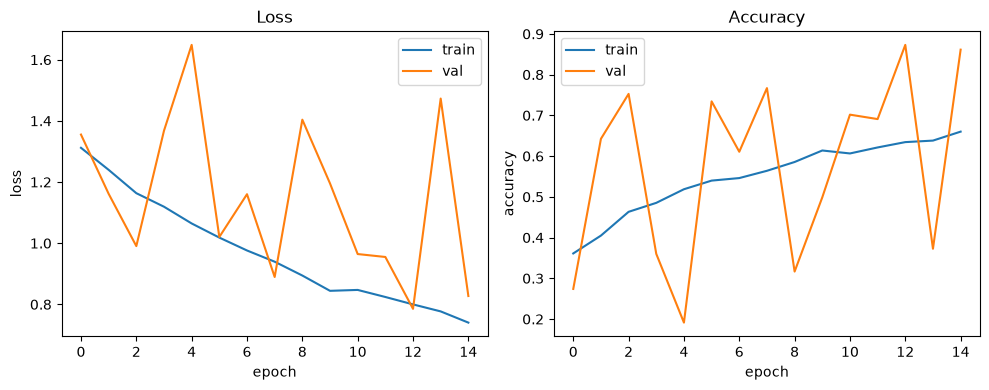

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # two side-by-side plots: loss, accuracy

axes[0].plot(history["train_loss"], label="train")  # x-axis defaults to 0, 1, 2, ... (epoch number)
axes[0].plot(history["val_loss"], label="val")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Evaluate

Overall accuracy is misleading here because the classes are so imbalanced — a model
that just always predicts "clean" would score ~85% accuracy while being useless. Two
better metrics:

- **Balanced accuracy**: average of the per-class recalls, so every class counts
  equally regardless of how common it is.
- **Quadratic weighted kappa (QWK)**: since the classes are ordered (clean < moderate
  < severe < ambiguous), this penalizes a clean/ambiguous mistake much more than a
  clean/moderate one. It's the metric the main project pipeline optimizes for, using a
  more advanced ordinal-regression loss (CORN) instead of the plain cross-entropy loss
  used here — worth reading about once this basic version makes sense to you.

In [12]:
model.eval()  # same reasoning as the validation pass during training
all_preds, all_targets = [], []
with torch.no_grad():
    for images, lbls in val_loader:
        logits = model(images.to(device))
        all_preds.append(logits.argmax(1).cpu().numpy())  # .cpu(): move off the GPU before converting to numpy
        all_targets.append(lbls.numpy())
preds = np.concatenate(all_preds)      # stitch all the per-batch prediction arrays into one long array
targets = np.concatenate(all_targets)  # ... and the same for true labels, in the same order

bal_acc = balanced_accuracy_score(targets, preds)
qwk = cohen_kappa_score(targets, preds, weights="quadratic")
print(f"balanced accuracy: {bal_acc:.3f}")
print(f"quadratic weighted kappa (QWK): {qwk:.3f}")
print()
print(classification_report(targets, preds, target_names=CLASS_NAMES, digits=2))  # precision/recall/F1 per class

balanced accuracy: 0.439
quadratic weighted kappa (QWK): 0.550

              precision    recall  f1-score   support

       clean       0.92      0.96      0.94      1029
    moderate       0.22      0.20      0.21        84
      severe       0.62      0.28      0.38        65
   ambiguous       0.55      0.32      0.40        19

    accuracy                           0.86      1197
   macro avg       0.58      0.44      0.48      1197
weighted avg       0.85      0.86      0.85      1197



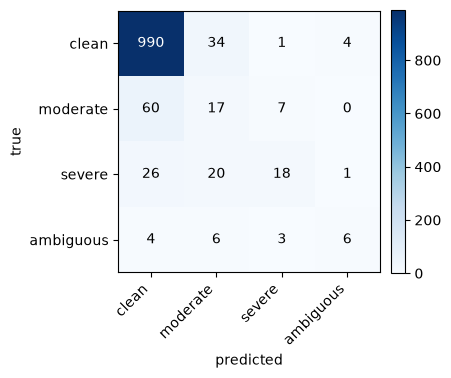

In [13]:
# cm[i, j] = number of cutouts whose true class is i and were predicted as class j.
# a perfect model would have all its counts on the diagonal (i == j).
cm = confusion_matrix(targets, preds, labels=range(NUM_CLASSES))

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")  # darker cell = higher count
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
thresh = cm.max() / 2  # used just below, so text stays readable on both dark and light cells
for r in range(NUM_CLASSES):
    for c in range(NUM_CLASSES):
        ax.text(c, r, cm[r, c], ha="center", va="center", color="white" if cm[r, c] > thresh else "black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # the count -> color-darkness legend
plt.tight_layout()
plt.show()

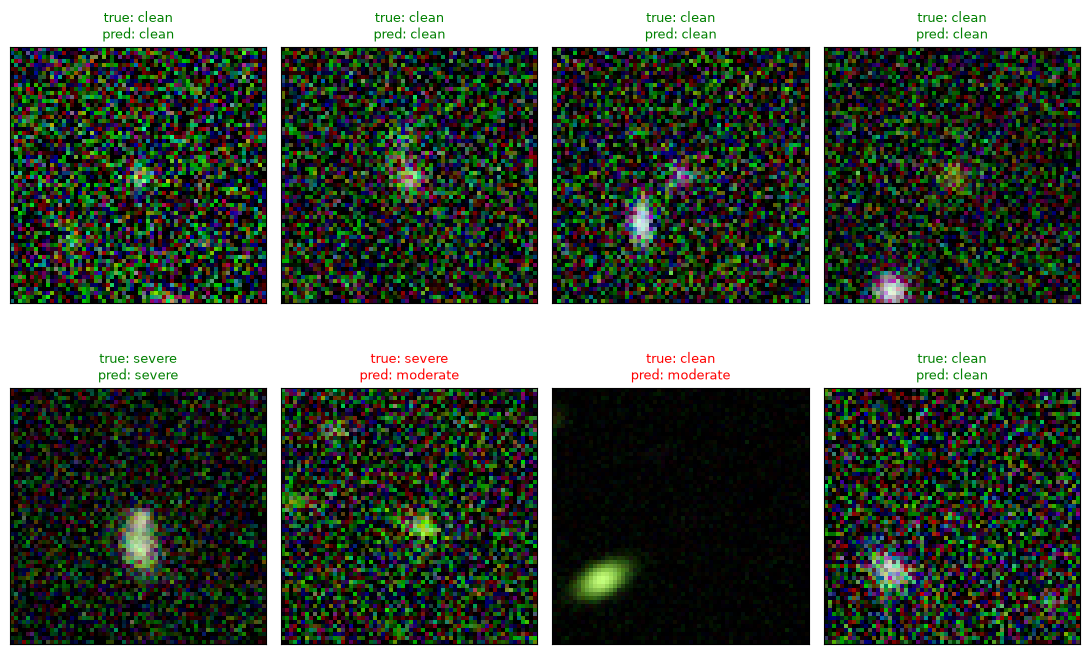

In [14]:
rng2 = np.random.RandomState(1)
sample_positions = rng2.choice(len(val_idx), size=8, replace=False)  # 8 random *positions within val_idx*

fig, axes = plt.subplots(2, 4, figsize=(11, 7))  # a 2x4 grid of example cutouts
for ax, pos in zip(axes.flat, sample_positions):  # axes.flat: iterate the grid as one flat list
    img_tensor, true_label = val_ds[pos]  # the normalized (network-ready) image + its true label
    with torch.no_grad():
        # unsqueeze(0) adds a batch dimension of size 1, since the model always expects a batch
        logits = model(img_tensor.unsqueeze(0).to(device))
        pred_label = logits.argmax(1).item()  # .item(): pull the single number out of a 1-element tensor

    # for display we go back to the *raw*, un-normalized pixels -- val_idx[pos] maps this
    # dataset position back to its row in images_arr/labels_df
    raw_img = np.asarray(images_arr[val_idx[pos]], dtype=np.float32)
    ax.imshow(to_rgb(raw_img))
    correct = pred_label == true_label
    ax.set_title(f"true: {CLASS_NAMES[true_label]}\npred: {CLASS_NAMES[pred_label]}",
                 fontsize=9, color="green" if correct else "red")  # green = model got it right, red = wrong
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout(h_pad=3)
plt.show()

## 9. Things to try

Go back to the **Settings** cell (Section 1), change one setting at a time, and
re-run from that cell down. Some things worth trying, and what to watch for:

- **`num_conv_blocks`** (try 2 vs 4): does a deeper network do better, or does it start
  overfitting (train accuracy high, val accuracy flat/worse)?
- **`base_channels`** (try 8, 16, 32): a wider network has more capacity but also more
  parameters to overfit with a small dataset — watch the parameter count printed in
  Section 6.
- **`use_class_weighting`** (try `False`): watch what happens to the `severe` and
  `ambiguous` rows in the confusion matrix specifically -- without oversampling, the
  model may barely predict them at all.
- **`use_augmentation`** (try `False`): does train accuracy pull further ahead of val
  accuracy?
- **`learning_rate`** (try `1e-2` and `1e-4`): too high can make the loss curve noisy
  or diverge; too low can make training barely move in 15 epochs.
- **`grad_clip`** (try `0.1` and `100`): a very small value slows learning (every
  update gets capped); a very large one effectively disables clipping -- watch the
  val accuracy curve get noisier if training was borderline unstable to begin with.
- **`epochs`** (try 40): does val loss keep improving, or does it bottom out and start
  rising while train loss keeps dropping (classic overfitting)?
- **`dropout`** (try 0.0 vs 0.5): how does it affect the train/val accuracy gap?

After experimenting, look at the confusion matrix and the example predictions grid —
do the mistakes make sense given what the class examples in Section 3 look like?